____
# Mean sla


In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance, compute_variance_groupby, plot_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [3]:
distance_to_coast_max = 20e3
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)

_______
# Generate 

In [5]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = drifter_preprocess,
        drifter_preprocess_param=drifter_preprocess_param,
        alti_product_key=alti_product_key,
        alti_diff_method = 'diff_only',
        alti_diff_method_param = '',
        ggd_var = 'etaf',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')

comb_list = [update_dict(base_dic, {'alti_diff_method':'fromduacsv', 'ggd_var':'fromduacsv'}), base_dic, update_dict(base_dic, {'ggd_var':'etafm'})]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',['fromduacsv', 'etaf', 'etafm'])
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth = '15'))
comb_list = [update_dict(base_dic, {'alti_diff_method':'fromduacsv', 'ggd_var':'fromduacsv'}), base_dic, update_dict(base_dic, {'ggd_var':'etafm'})]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',['fromduacsv', 'etaf', 'etafm'])
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<max_ggd) & (abs(DS.ggdn)<max_ggd), drop=True)
DSG = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)


# Closure figs
dsg = compute_variance(DSG, compute_error='centrallimit')/U2



321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio0
215697
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_diff_only__etaf__era5_rio0
215697
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_diff_only__etafm__era5_rio0
Identified SWOT and drifter outliers have been removed
321898
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_fromduacsv__fromduacsv__era5_rio15
215697
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_diff_only__etaf__era5_rio15
215697
12h_spectral_decomp_all_med_variational_10min_v1____swot2km_diff_only__etafm__era5_rio15
Identified SWOT and drifter outliers have been removed


NameError: name 'extract_mean_geo' is not defined

# Distance to coast

# Temporal binned

In [7]:
DS['id_comb'] = ['L3-2km', 'L3-2km-filtered', 'L3-2km - mean anomaly']

13.418702083838395
13.921930189179328
13.379230033855922
13.881703325436966
12.946906036591793
13.35666911600126


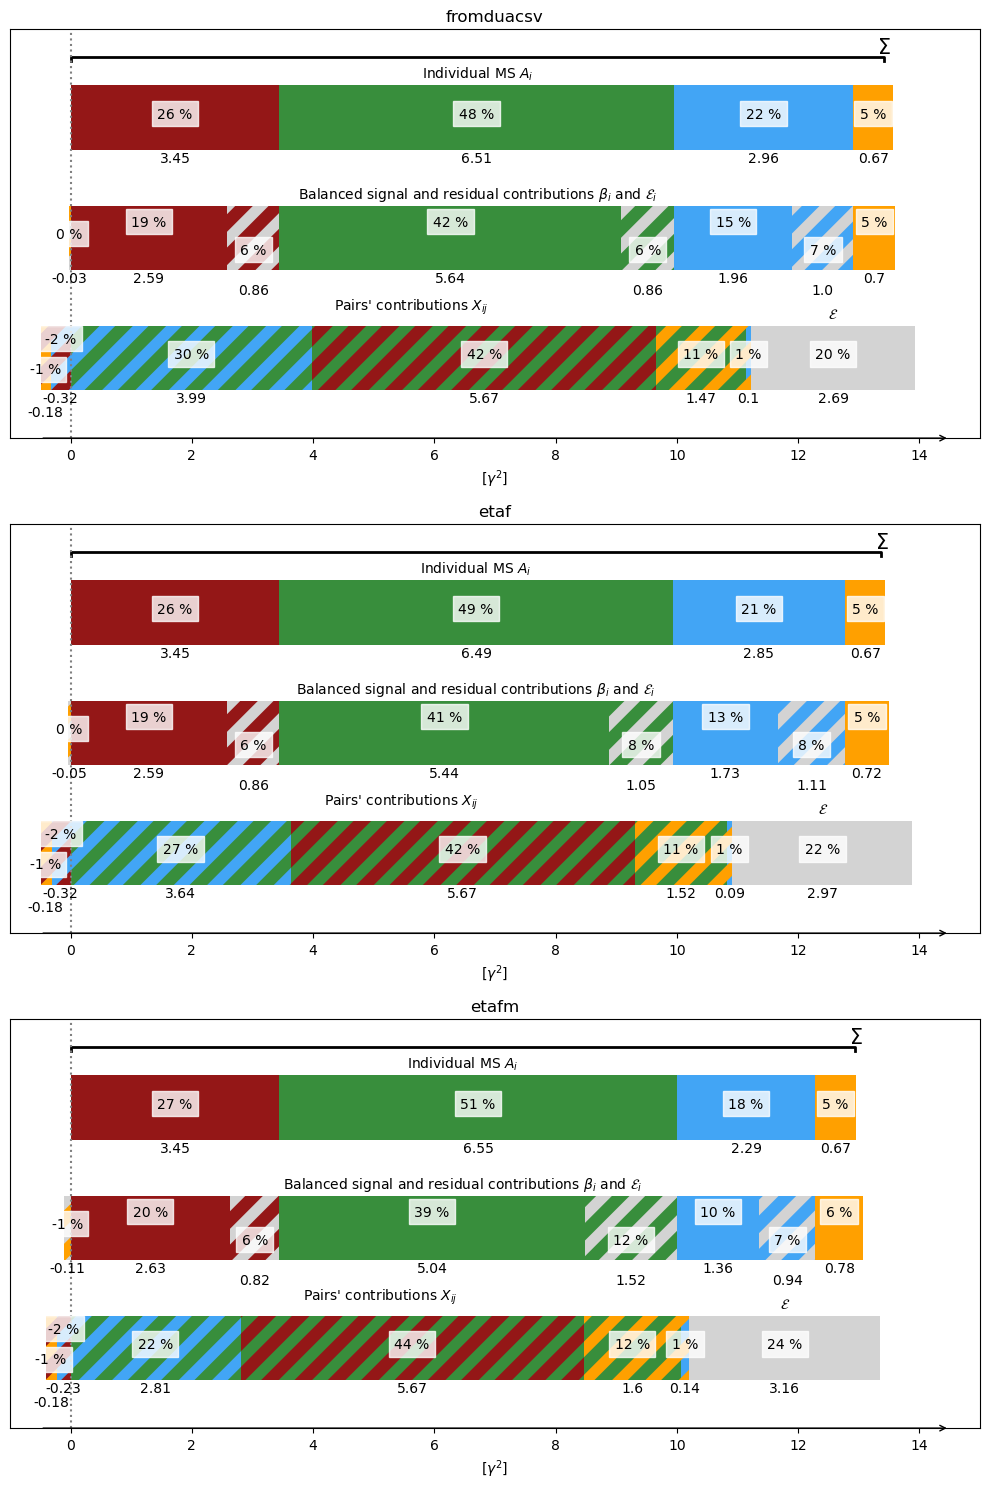

In [5]:
dfg = dsg.to_dataframe()
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(10,15), frameon=False)
synthetic_figure(dfg.iloc[0], ax=axs[0], dir='', xlim=[-1, 14.5])
synthetic_figure(dfg.iloc[1], ax=axs[1], dir='', xlim=[-1, 14.5])
synthetic_figure(dfg.iloc[2], ax=axs[2], dir='', xlim=[-1, 14.5])

for i in range(len(dfg)):
    axs[i].set_title(dfg.reset_index().id_comb.iloc[i])
fig.tight_layout()


13.418702083838395
13.921930189179328
13.379230033855919
13.881703325436963
12.946906036591793
13.35666911600126


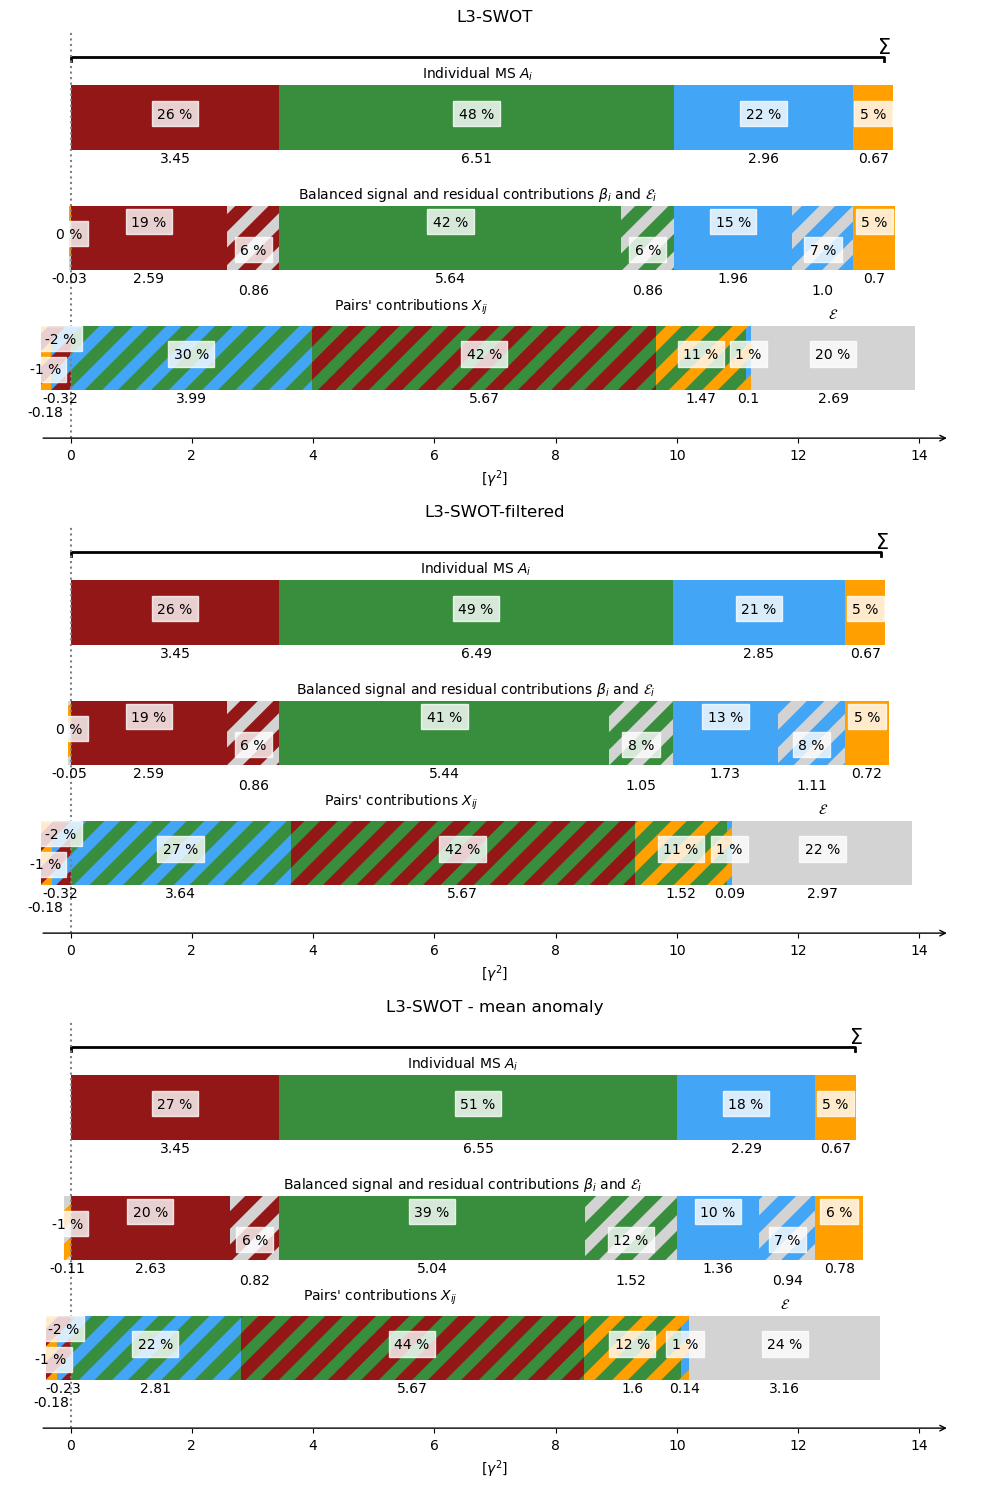

In [10]:
dfg = dsg.to_dataframe()
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(10,15), frameon=False)
synthetic_figure(dfg.iloc[0], ax=axs[0], dir='', xlim=[-1, 14.5])
synthetic_figure(dfg.iloc[1], ax=axs[1], dir='', xlim=[-1, 14.5])
synthetic_figure(dfg.iloc[2], ax=axs[2], dir='', xlim=[-1, 14.5])

for i in range(len(dfg)):
    axs[i].set_title(dfg.reset_index().id_comb.iloc[i])
fig.tight_layout()


# Distance to coast

In [9]:
compute_error = 'centrallimit'
D=[]
for c in DS.id_comb :
    df = DS.sel(id_comb=c).to_dataframe()
    dtc_bins = np.arange(0, 200e3, 5e3)
    df['dtc_cut'] = pd.cut(df['distance_to_coast'], dtc_bins, labels=(dtc_bins[1:] + dtc_bins[:-1])/2)
    dsdtc = compute_variance_groupby(df, groupby = 'dtc_cut', dirname = ('e', 'n'), compute_error =compute_error, vars_errors = ['Ex_ggd', 'Ey_ggd'] )
    dsdtc = dsdtc.where(dsdtc.nb_coloc>100).dropna('dtc_cut')
    dsdtc['dtc_cut'] = dsdtc.dtc_cut/1000
    dsdtc['id_comb']=c
    D.append(dsdtc)
dsdtc = xr.concat(D, dim='id_comb')


/home1/datahome/mdemol/med_analysis/diagnosis.py:619: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfm = (df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]] - df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]].groupby(groupby).mean()).reset_index()


dtc_cut
2500.0          0
7500.0          8
12500.0       925
17500.0      3684
22500.0      6123
27500.0      7815
32500.0      8746
37500.0      8949
42500.0      8668
47500.0     10420
52500.0     10211
57500.0     10383
62500.0      9266
67500.0     11339
72500.0     11369
77500.0      8560
82500.0      9174
87500.0      8479
92500.0      5909
97500.0      4927
102500.0     5942
107500.0     6603
112500.0     7519
117500.0     7268
122500.0     6039
127500.0     3774
132500.0     3404
137500.0     2496
142500.0     2649
147500.0     2236
152500.0     2247
157500.0     2854
162500.0     1330
167500.0     1916
172500.0     1922
177500.0     1967
182500.0      517
187500.0        0
192500.0        0
Name: acce, dtype: int64
dtc_cut
2500.0       1
7500.0       1
12500.0      6
17500.0     18
22500.0     41
27500.0     36
32500.0     45
37500.0     41
42500.0     28
47500.0     37
52500.0     58
57500.0     53
62500.0     52
67500.0     65
72500.0     69
77500.0     54
82500.0     58
87

/home1/datahome/mdemol/med_analysis/diagnosis.py:619: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfm = (df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]] - df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]].groupby(groupby).mean()).reset_index()


dtc_cut
2500.0          0
7500.0          8
12500.0       925
17500.0      3684
22500.0      6123
27500.0      7815
32500.0      8746
37500.0      8949
42500.0      8668
47500.0     10420
52500.0     10211
57500.0     10383
62500.0      9266
67500.0     11339
72500.0     11369
77500.0      8560
82500.0      9174
87500.0      8479
92500.0      5909
97500.0      4927
102500.0     5942
107500.0     6603
112500.0     7519
117500.0     7268
122500.0     6039
127500.0     3774
132500.0     3404
137500.0     2496
142500.0     2649
147500.0     2236
152500.0     2247
157500.0     2854
162500.0     1330
167500.0     1916
172500.0     1922
177500.0     1967
182500.0      517
187500.0        0
192500.0        0
Name: acce, dtype: int64
dtc_cut
2500.0       1
7500.0       1
12500.0      6
17500.0     18
22500.0     41
27500.0     36
32500.0     45
37500.0     41
42500.0     28
47500.0     37
52500.0     58
57500.0     53
62500.0     52
67500.0     65
72500.0     69
77500.0     54
82500.0     58
87

/home1/datahome/mdemol/med_analysis/diagnosis.py:619: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfm = (df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]] - df.set_index(groupby)[[v+dirname[1] for v in var] + [v+dirname[0] for v in var]].groupby(groupby).mean()).reset_index()


dtc_cut
2500.0          0
7500.0          8
12500.0       925
17500.0      3684
22500.0      6123
27500.0      7815
32500.0      8746
37500.0      8949
42500.0      8668
47500.0     10420
52500.0     10211
57500.0     10383
62500.0      9266
67500.0     11339
72500.0     11369
77500.0      8560
82500.0      9174
87500.0      8479
92500.0      5909
97500.0      4927
102500.0     5942
107500.0     6603
112500.0     7519
117500.0     7268
122500.0     6039
127500.0     3774
132500.0     3404
137500.0     2496
142500.0     2649
147500.0     2236
152500.0     2247
157500.0     2854
162500.0     1330
167500.0     1916
172500.0     1922
177500.0     1967
182500.0      517
187500.0        0
192500.0        0
Name: acce, dtype: int64
dtc_cut
2500.0       1
7500.0       1
12500.0      6
17500.0     18
22500.0     41
27500.0     36
32500.0     45
37500.0     41
42500.0     28
47500.0     37
52500.0     58
57500.0     53
62500.0     52
67500.0     65
72500.0     69
77500.0     54
82500.0     58
87

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/core/dataset.py:4789: UserWarning: No index created for dimension id_comb because variable id_comb is not a coordinate. To create an index for id_comb, please first call `.set_coords('id_comb')` on this object.
  warnings.warn(


In [72]:
dsdtc

<xarray.Dataset> Size: 40kB
Dimensions:            (dtc_cut: 35)
Coordinates:
  * dtc_cut            (dtc_cut) float64 280B 12.5 17.5 22.5 ... 177.5 182.5
Data variables: (12/142)
    ACCe               (dtc_cut) float64 280B 1.293 1.25 1.501 ... 0.7778 0.9398
    CORe               (dtc_cut) float64 280B 2.643 2.037 2.119 ... 1.211 1.004
    GGDe               (dtc_cut) float64 280B 0.4021 0.5966 ... 0.3437 0.6244
    WDe                (dtc_cut) float64 280B 0.2215 0.2269 ... 0.08701 0.06688
    Se                 (dtc_cut) float64 280B 2.144 2.161 ... 0.7727 0.3977
    sigmae             (dtc_cut) float64 280B 4.559 4.11 4.488 ... 2.419 2.635
    ...                 ...
    ser__D_anticyclo   (dtc_cut) float64 280B 0.5976 0.2656 ... 0.204 0.3102
    ser__MEANCORe      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANGGDe      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANCORn      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANGGDn      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    id_comb            <U22 88B 'L3-SWOT - mean anomaly'

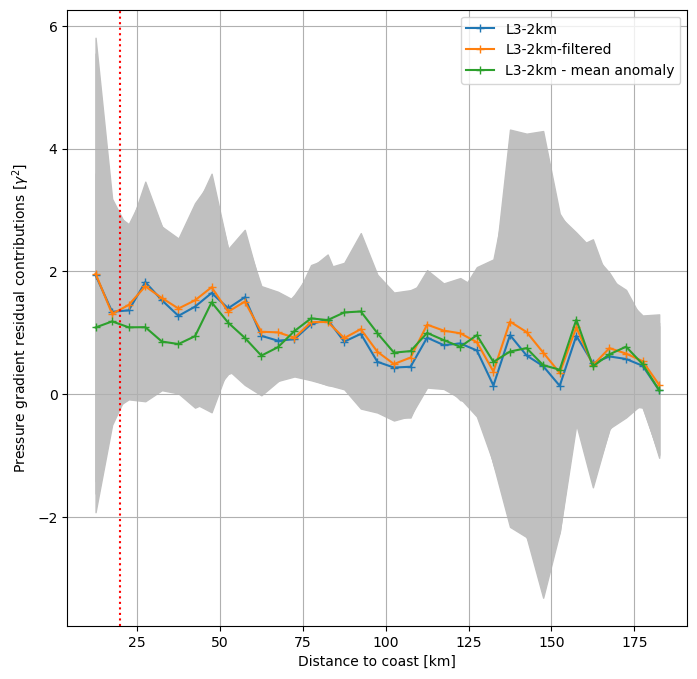

In [10]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
for dsdtc in D:
    dsdtc.E_ggd.plot(ax=ax,label = f'{dsdtc.id_comb.values}', marker='+')
    dsdtc['er__E_ggd'] = dsdtc.er__Ee_ggd + dsdtc.er__En_ggd
    plot_error(dsdtc, 'dtc_cut', 'E_ggd', ax=ax, suf='er__')
    ax.set_ylabel(r'Pressure gradient residual contributions [$\gamma^2$]')
    

ax.axvline(20, ls=':',c='r' )
ax.grid()
ax.set_xlabel(r'Distance to coast [km]')
ax.legend()

In [85]:
dsdtc

<xarray.Dataset> Size: 40kB
Dimensions:            (dtc_cut: 35)
Coordinates:
  * dtc_cut            (dtc_cut) float64 280B 12.5 17.5 22.5 ... 177.5 182.5
Data variables: (12/142)
    ACCe               (dtc_cut) float64 280B 1.293 1.25 1.501 ... 0.7778 0.9398
    CORe               (dtc_cut) float64 280B 2.643 2.037 2.119 ... 1.211 1.004
    GGDe               (dtc_cut) float64 280B 0.4021 0.5966 ... 0.3437 0.6244
    WDe                (dtc_cut) float64 280B 0.2215 0.2269 ... 0.08701 0.06688
    Se                 (dtc_cut) float64 280B 2.144 2.161 ... 0.7727 0.3977
    sigmae             (dtc_cut) float64 280B 4.559 4.11 4.488 ... 2.419 2.635
    ...                 ...
    ser__D_anticyclo   (dtc_cut) float64 280B 0.5976 0.2656 ... 0.204 0.3102
    ser__MEANCORe      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANGGDe      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANCORn      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ser__MEANGGDn      (dtc_cut) float64 280B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    id_comb            <U21 84B 'L3-2km - mean anomaly'

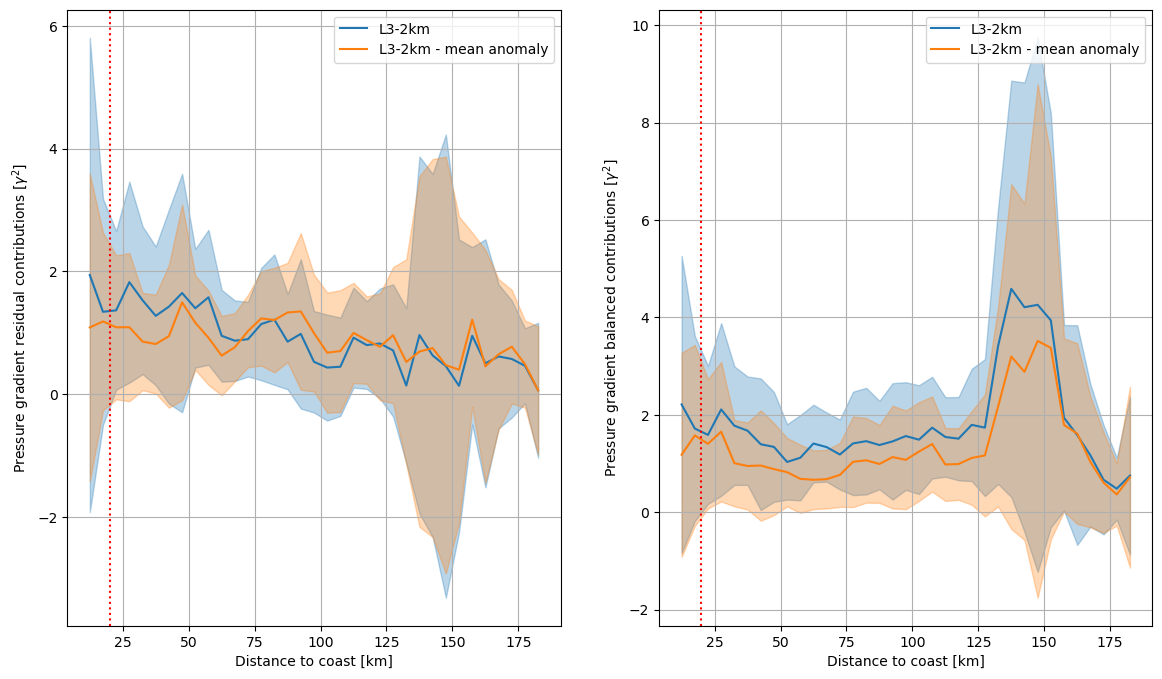

In [13]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1, 2, figsize=(14,8), frameon=False)
i = 0
c = ['tab:blue', 'tab:orange']
for dsdtc in [D[0], D[2]]:
    ax=axs[0]
    dsdtc.E_ggd.plot(ax=ax,label = f'{dsdtc.id_comb.values}')
    dsdtc['er___E_ggd'] = dsdtc.er__Ee_ggd + dsdtc.er__En_ggd
    plot_error(dsdtc, 'dtc_cut', 'E_ggd', ax=ax, suf='er__',  color=c[i], alpha=0.3)
    ax.set_ylabel(r'Pressure gradient residual contributions [$\gamma^2$]')
    
    ax=axs[1]
    dsdtc.B_ggd.plot(ax=ax, label = f'{dsdtc.id_comb.values}')
    dsdtc['er__B_ggd'] = dsdtc.er__Be_ggd + dsdtc.er__Bn_ggd
    plot_error(dsdtc, 'dtc_cut', 'B_ggd', ax=ax, suf='er__',  color=c[i], alpha=0.3)
    ax.set_ylabel(r'Pressure gradient balanced contributions [$\gamma^2$]')
    i+=1

for ax in axs :
    ax.axvline(20, ls=':',c='r' )
    ax.grid()
    ax.set_xlabel(r'Distance to coast [km]')
    ax.legend()

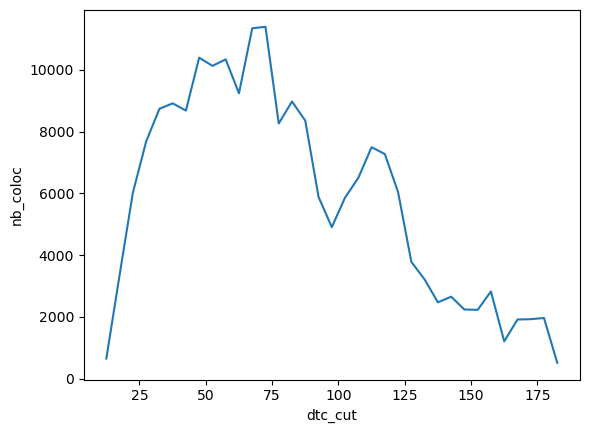

In [75]:
dsdtc.nb_coloc.plot()

In [20]:
0.**2

0.0361

In [7]:
A = 141464.15110761
def sigmassh(E_ggd) : return np.sqrt(E_ggd/A)
def E_ggd(sigmassh) : return A*sigmassh**2
#
#sigmassh(df.E_ggd)/1e-2 # cm

In [18]:
E_ggd(0.32*1e-2), sigmassh(0.5)

(1.4485929073419264, np.float64(0.0018800171163652446))

In [ ]:
0.51, 1.44

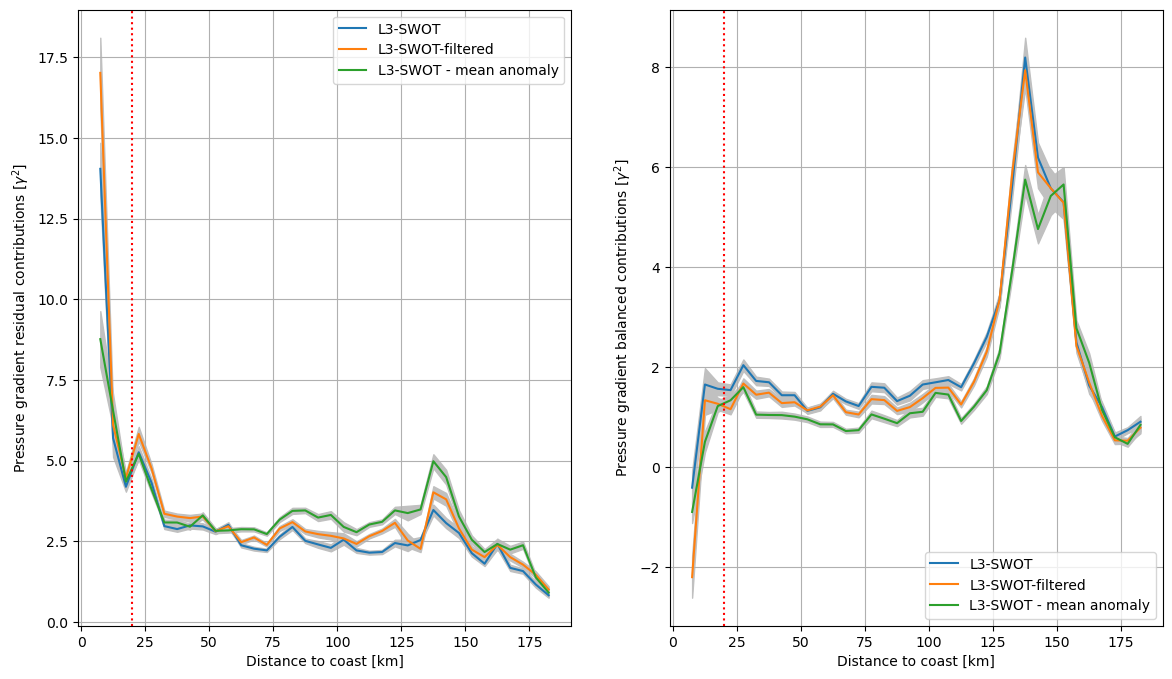

In [20]:
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(1, 2, figsize=(14,8), frameon=False)
for dsdtc in D:
    ax=axs[0]
    dsdtc.S.plot(ax=ax,label = f'{dsdtc.id_comb.values}')
    dsdtc['er___S'] = dsdtc.er__Se + dsdtc.er__Sn
    plot_error(dsdtc, 'dtc_cut', 'S', ax=ax, suf='er__')
    ax.set_ylabel(r'Pressure gradient residual contributions [$\gamma^2$]')
    
    ax=axs[1]
    dsdtc.B_ggd.plot(ax=ax, label = f'{dsdtc.id_comb.values}')
    dsdtc['er__B_ggd'] = dsdtc.er__Be_ggd + dsdtc.er__Bn_ggd
    plot_error(dsdtc, 'dtc_cut', 'B_ggd', ax=ax, suf='er__')
    ax.set_ylabel(r'Pressure gradient balanced contributions [$\gamma^2$]')

for ax in axs :
    ax.axvline(20, ls=':',c='r' )
    ax.grid()
    ax.set_xlabel(r'Distance to coast [km]')
    ax.legend()

# lon lat

In [11]:
dl=0.01
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)

Dl=[]
for c in DS.id_comb :
    df = DS.sel(id_comb=c).to_dataframe()
    df['longitude_cut']= pd.cut(df['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
    df['latitude_cut']= pd.cut(df['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
    ds = compute_variance_groupby(df, groupby = [ 'latitude_cut','longitude_cut'])
    Dl.append(ds)

In [12]:
diff = (Dl[0] - Dl[2])

(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 3.000e+00, 3.000e+00, 5.000e+00, 4.000e+00, 1.200e+01,
        9.000e+00, 1.100e+01, 1.400e+01, 2.400e+01, 3.700e+01, 5.300e+01,
        8.000e+01, 1.090e+02, 1.720e+02, 2.370e+02, 3.710e+02, 5.720e+02,
        8.750e+02, 1.416e+03, 2.346e+03, 3.398e+03, 3.298e+03, 2.125e+03,
        1.357e+03, 9.350e+02, 5.990e+02, 3.750e+02, 2.920e+02, 1.850e+02,
        1.540e+02, 1.010e+02, 9.400e+01, 6.500e+01, 5.000e+01, 3.500e+01,
        3.000e+01, 2.800e+01, 2.400e+01, 2.100e+01, 1.000e+01, 9.000e+00,
        8.000e+00, 7.000e+00, 8.000e+00, 1.000e+00, 6.000e+00, 4.000e+00,
        3.000e+00, 5.000e+00, 4.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        6.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00]),
 array([-20. , -1

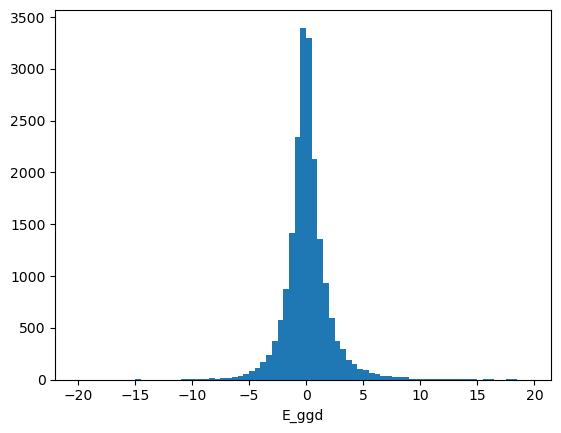

In [13]:
diff.E_ggd.plot.hist(bins = np.arange(-20, 20, 0.5))

In [14]:
ds3m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass3_swot2km_meansla.nc'))
ds16m = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot2km', f'pass16_swot2km_meansla.nc'))

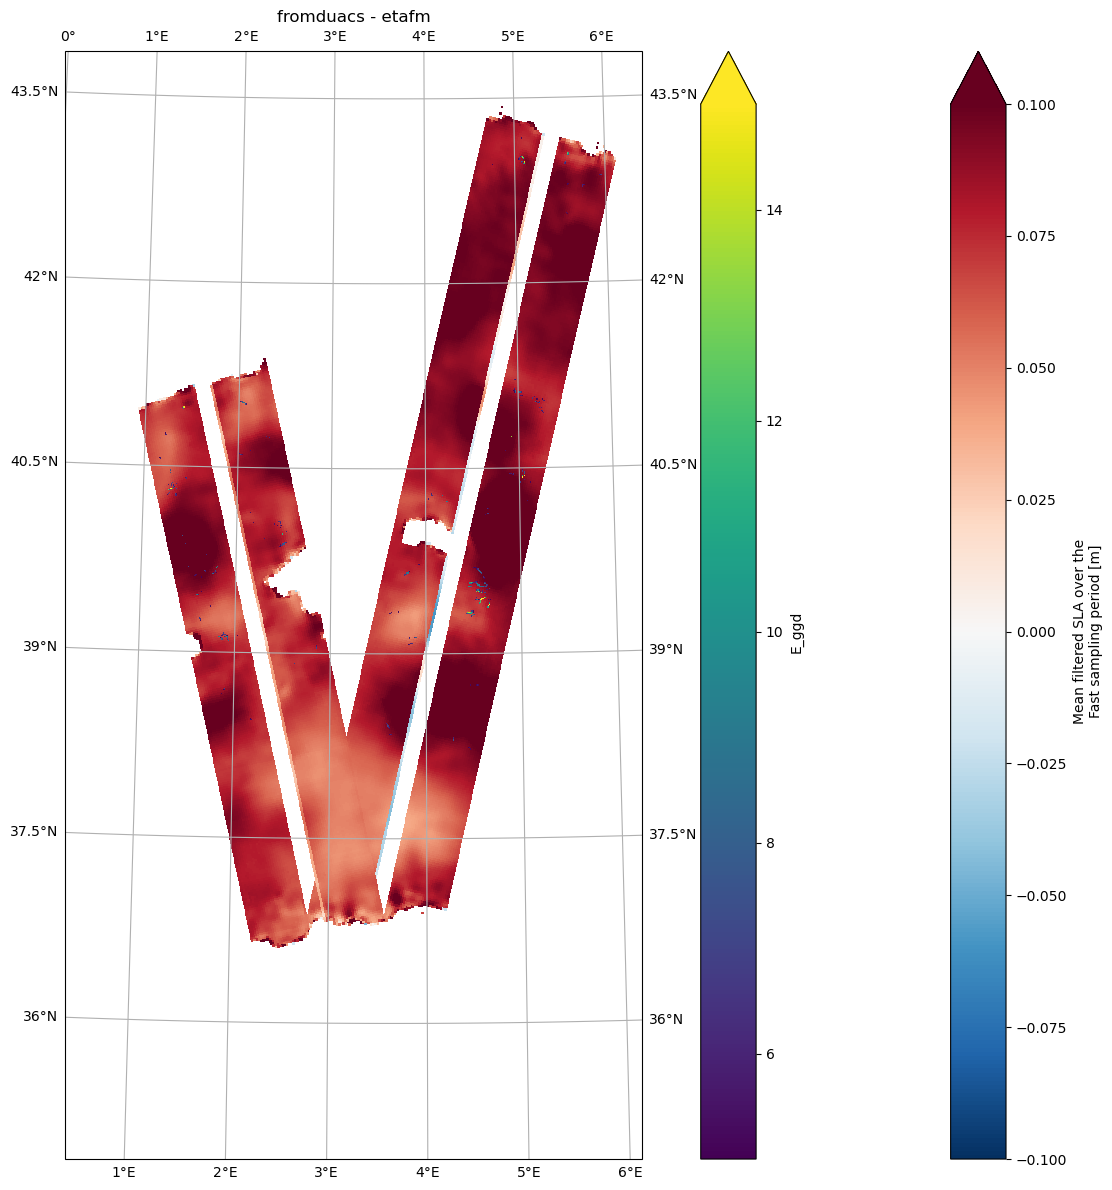

In [15]:
fig = plt.figure(figsize=(15,12))
vmin, vmax = -0.1, 0.1

ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
ds3m.mean_slaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ds16m.mean_slaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax, cmap='RdBu_r')
diff.where(diff.E_ggd>5).E_ggd.plot(ax=ax, transform=crs, vmax=15, cmap='viridis')#, **xstyle[xn.replace('Xn_', '')])
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
ax.set_title('fromduacs - etafm')  
fig.tight_layout()

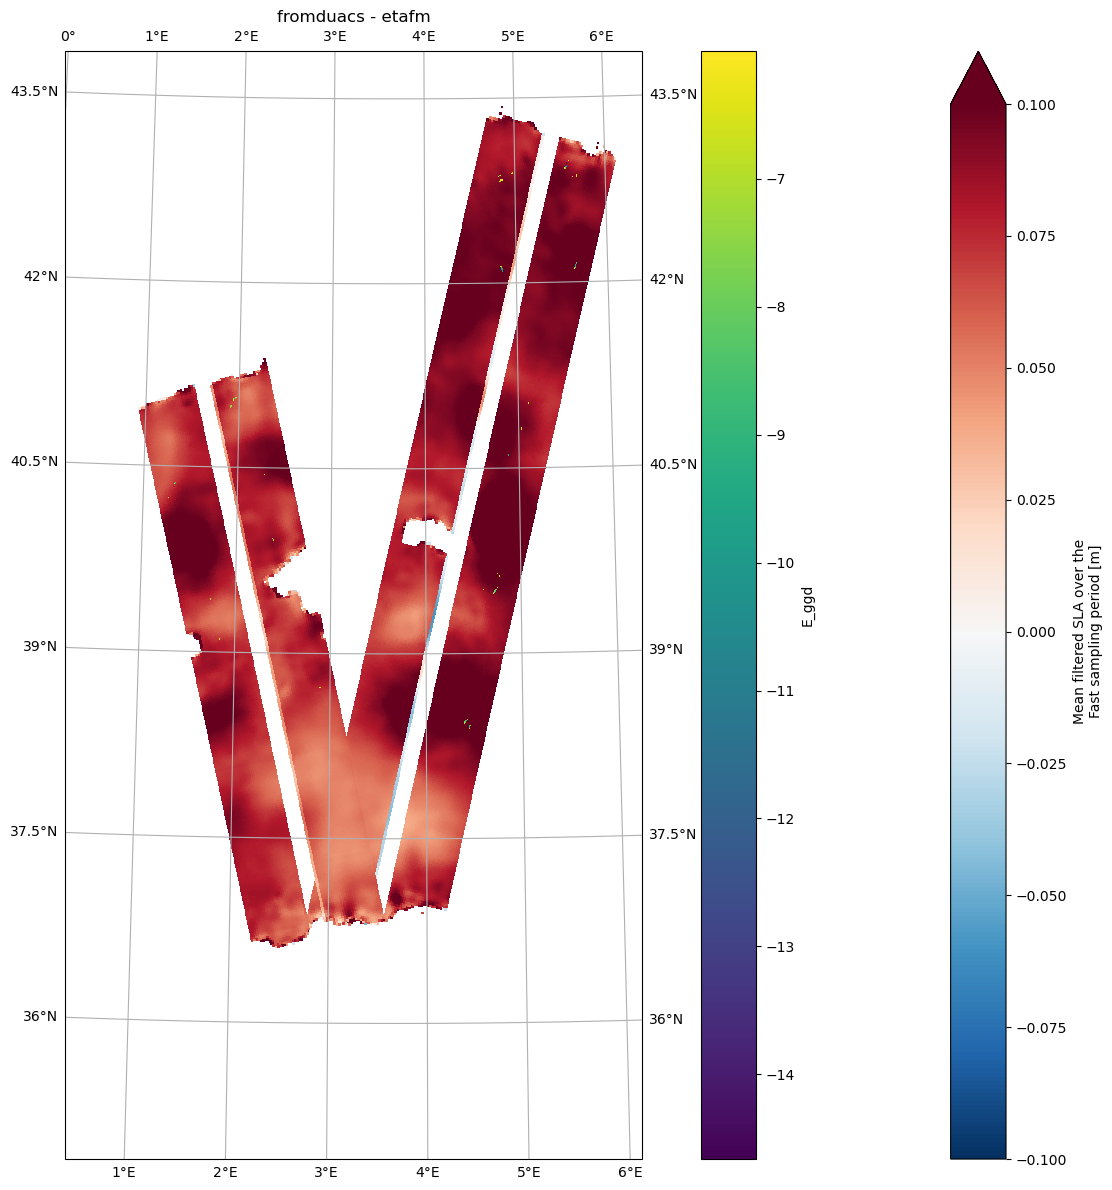

In [16]:
fig = plt.figure(figsize=(15,12))
vmin, vmax = -0.1, 0.1

ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
ds3m.mean_slaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, vmin=vmin, vmax=vmax, cmap='RdBu_r')
ds16m.mean_slaf.plot(x='longitude', y='latitude',ax=ax, transform=crs, add_colorbar=False, vmin=vmin, vmax=vmax, cmap='RdBu_r')
diff.where(diff.E_ggd<-6).E_ggd.plot(ax=ax, transform=crs, cmap='viridis')#, **xstyle[xn.replace('Xn_', '')])
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
ax.set_title('fromduacs - etafm')  
fig.tight_layout()

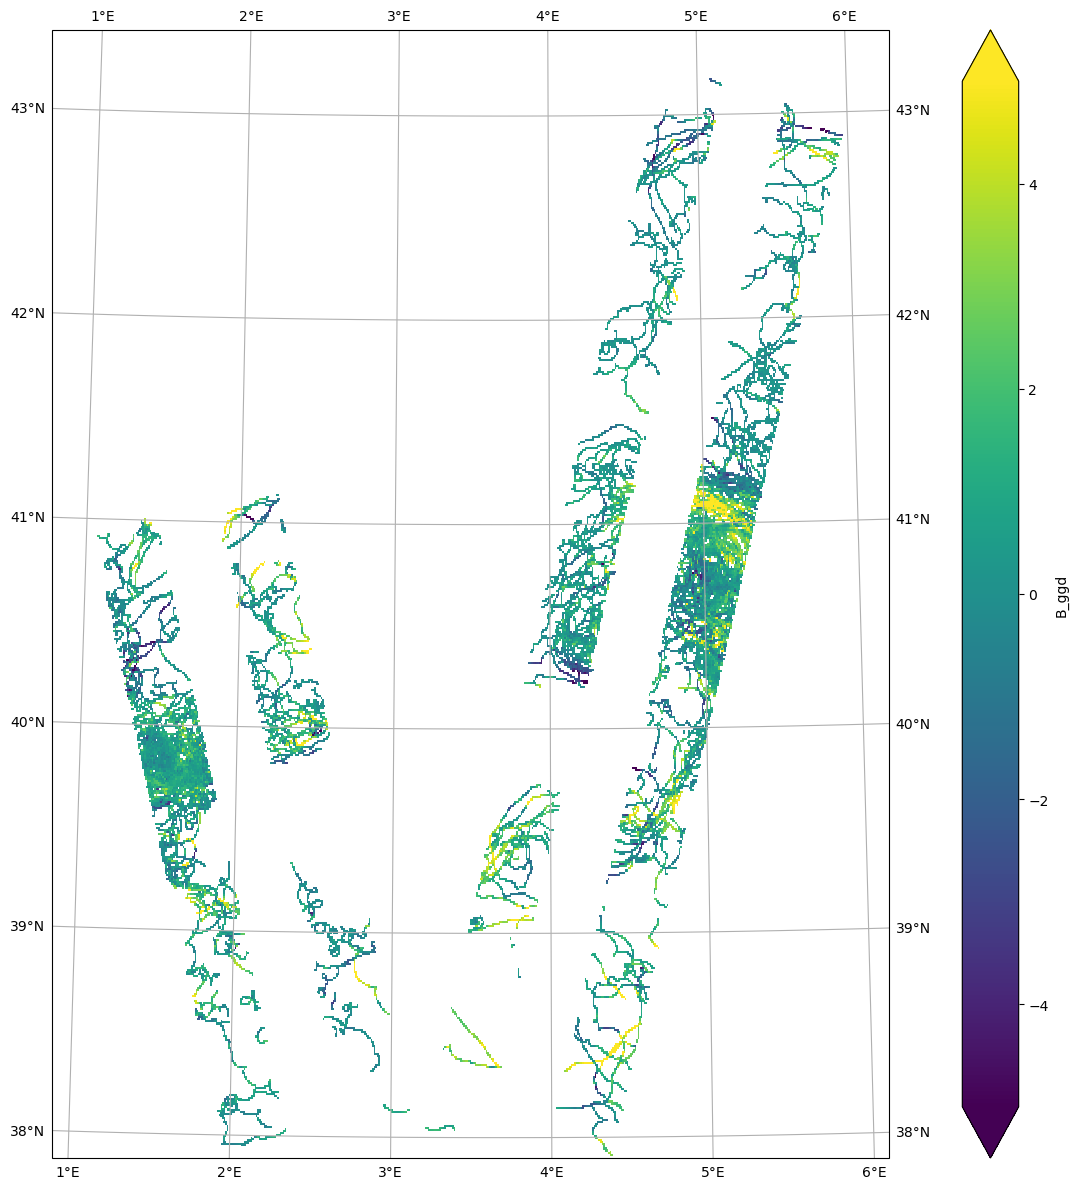

In [17]:
fig = plt.figure(figsize=(15,12))

ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
diff.B_ggd.plot(ax=ax, transform=crs, cmap = 'viridis', vmin=-5, vmax=5)#, **xstyle[xn.replace('Xn_', '')])
#ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
    
fig.tight_layout()